# Homework 1: measurements, calibration and plots
Run this notebook from top to bottom on a Kaggle T4 x2 accelerator. Only physical GPU 0 is exposed to PyTorch.

In [1]:
%env CUDA_VISIBLE_DEVICES=0
!git clone --depth 1 https://github.com/kostkornilov/hw1.git /kaggle/working/hw1
%cd /kaggle/working/hw1
!git pull
%pip install -q nvidia-ml-py

env: CUDA_VISIBLE_DEVICES=0
Cloning into '/kaggle/working/hw1'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 10 (delta 0), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 103.58 KiB | 3.24 MiB/s, done.
/kaggle/working/hw1
Already up to date.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import json
import math
import random
import threading
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynvml
import torch
from torch.profiler import ProfilerActivity, profile

from calibrate import save_calibration
from equations import bytes_moved, energy, flops, latency, memory
from models import SimpleCNN

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False

device = torch.device("cuda:0")
model = SimpleCNN().to(device).eval()

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
MEASUREMENTS_PATH = RESULTS_DIR / "measurements.csv"
THETA_PATH = RESULTS_DIR / "theta.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch: {torch.__version__}, CUDA: {torch.version.cuda}")

GPU: Tesla T4
PyTorch: 2.10.0+cu128, CUDA: 12.8


## Reproducible measurement grid

In [3]:
BASE_IMAGE_SIZES = [32, 64, 128, 224, 256, 384, 512]
BASE_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256]

grid_rng = random.Random(SEED)
image_candidates = [
    value for value in range(32, 513, 16) if value not in BASE_IMAGE_SIZES
]
sampled_image_sizes = sorted(grid_rng.sample(image_candidates, 4))
batch_candidates = [
    value for value in range(1, 257) if value not in BASE_BATCH_SIZES
]
sampled_batch_sizes = sorted(grid_rng.sample(batch_candidates, 3))

image_sizes = sorted(BASE_IMAGE_SIZES + sampled_image_sizes)
batch_sizes = sorted(BASE_BATCH_SIZES + sampled_batch_sizes)
grid = pd.MultiIndex.from_product(
    [image_sizes, batch_sizes], names=["image_size", "batch"]
).to_frame(index=False)
grid["is_validation"] = (
    ~grid["image_size"].isin(BASE_IMAGE_SIZES)
    | ~grid["batch"].isin(BASE_BATCH_SIZES)
)
assert len(grid) == 132

print(f"Image sizes: {image_sizes} (sampled: {sampled_image_sizes})")
print(f"Batch sizes: {batch_sizes} (sampled: {sampled_batch_sizes})")
print(grid["is_validation"].value_counts().rename(index={False: "train", True: "validation"}))

Image sizes: [32, 48, 64, 112, 128, 224, 256, 384, 448, 496, 512] (sampled: [48, 112, 448, 496])
Batch sizes: [1, 2, 4, 8, 16, 32, 64, 65, 70, 78, 128, 256] (sampled: [65, 70, 78])
is_validation
validation    69
train         63
Name: count, dtype: int64


## Measurement helpers

In [4]:
pynvml.nvmlInit()
nvml_handle = pynvml.nvmlDeviceGetHandleByIndex(0)

try:
    pynvml.nvmlDeviceGetTotalEnergyConsumption(nvml_handle)
    cumulative_energy_supported = True
except pynvml.NVMLError:
    cumulative_energy_supported = False

def synchronize():
    torch.cuda.synchronize(device)


def warm_up(input_tensor, repeats=3):
    for _ in range(repeats):
        model(input_tensor)
    synchronize()


def timed_forward(input_tensor):
    synchronize()
    started = time.perf_counter()
    model(input_tensor)
    synchronize()
    return time.perf_counter() - started


def measure_latency(input_tensor):
    probe_s = timed_forward(input_tensor)
    repeats = int(np.clip(math.ceil(0.25 / max(probe_s, 1e-9)), 10, 100))
    samples = np.array([timed_forward(input_tensor) for _ in range(repeats)])
    return float(np.median(samples)), repeats, probe_s


def measure_peak_memory(input_tensor):
    torch.cuda.reset_peak_memory_stats(device)
    model(input_tensor)
    synchronize()
    return int(torch.cuda.max_memory_allocated(device))


def measure_profiler_flops(input_tensor):
    activities = [ProfilerActivity.CPU, ProfilerActivity.CUDA]
    with profile(activities=activities, with_flops=True) as prof:
        model(input_tensor)
        synchronize()
    return int(sum(event.flops or 0 for event in prof.key_averages()))


def _energy_repeats(probe_s):
    return int(np.clip(math.ceil(2.0 / max(probe_s, 1e-9)), 10, 10_000))


def measure_energy_counter(input_tensor, repeats):
    synchronize()
    before_mj = pynvml.nvmlDeviceGetTotalEnergyConsumption(nvml_handle)
    for _ in range(repeats):
        model(input_tensor)
    synchronize()
    after_mj = pynvml.nvmlDeviceGetTotalEnergyConsumption(nvml_handle)
    return (after_mj - before_mj) / 1_000.0 / repeats


def measure_energy_polling(input_tensor, repeats, interval_s=0.02):
    samples = []
    stop = threading.Event()

    def read_power():
        return pynvml.nvmlDeviceGetPowerUsage(nvml_handle) / 1_000.0

    def sampler():
        while not stop.wait(interval_s):
            samples.append((time.perf_counter(), read_power()))

    synchronize()
    started = time.perf_counter()
    samples.append((started, read_power()))
    thread = threading.Thread(target=sampler, daemon=True)
    thread.start()
    for _ in range(repeats):
        model(input_tensor)
    synchronize()
    finished = time.perf_counter()
    stop.set()
    thread.join()
    samples.append((finished, read_power()))

    samples.sort()
    timestamps = np.array([sample[0] for sample in samples])
    powers_w = np.array([sample[1] for sample in samples])
    return float(np.trapz(powers_w, timestamps) / repeats)


def measure_energy(input_tensor, probe_s):
    repeats = _energy_repeats(probe_s)
    if cumulative_energy_supported:
        try:
            return measure_energy_counter(input_tensor, repeats), repeats, "nvml_counter"
        except pynvml.NVMLError:
            pass
    return measure_energy_polling(input_tensor, repeats), repeats, "nvml_power_polling"

print(f"NVML cumulative energy supported: {cumulative_energy_supported}")

NVML cumulative energy supported: True


## Run or resume all 132 configurations

In [5]:
if MEASUREMENTS_PATH.exists():
    measurements = pd.read_csv(MEASUREMENTS_PATH)
else:
    measurements = pd.DataFrame()

if measurements.empty:
    completed = set()
else:
    completed = set(
        zip(measurements["image_size"].astype(int), measurements["batch"].astype(int))
    )

measurement_order = grid.sample(frac=1, random_state=SEED + 1).to_dict("records")
gpu_total_memory = int(torch.cuda.get_device_properties(0).total_memory)

for index, config in enumerate(measurement_order, start=1):
    image_size = int(config["image_size"])
    batch = int(config["batch"])
    key = (image_size, batch)
    if key in completed:
        continue

    record = {
        "image_size": image_size,
        "batch": batch,
        "is_validation": bool(config["is_validation"]),
        "oom": False,
        "latency_s": np.nan,
        "memory_bytes": np.nan,
        "energy_j": np.nan,
        "profiler_flops": np.nan,
        "latency_repeats": 0,
        "energy_repeats": 0,
        "energy_backend": "",
        "gpu_total_memory_bytes": gpu_total_memory,
    }
    input_tensor = None

    try:
        gc.collect()
        torch.cuda.empty_cache()
        input_tensor = torch.randn(batch, 3, image_size, image_size, device=device)
        with torch.inference_mode():
            warm_up(input_tensor)
            latency_s, latency_repeats, probe_s = measure_latency(input_tensor)
            record["latency_s"] = latency_s
            record["latency_repeats"] = latency_repeats
            record["memory_bytes"] = measure_peak_memory(input_tensor)
            record["profiler_flops"] = measure_profiler_flops(input_tensor)
            energy_j, energy_repeats, backend = measure_energy(input_tensor, probe_s)
            record["energy_j"] = energy_j
            record["energy_repeats"] = energy_repeats
            record["energy_backend"] = backend
    except torch.cuda.OutOfMemoryError:
        record["oom"] = True
    finally:
        del input_tensor
        gc.collect()
        torch.cuda.empty_cache()

    measurements = pd.concat([measurements, pd.DataFrame([record])], ignore_index=True)
    measurements = (
        measurements.drop_duplicates(["image_size", "batch"], keep="last")
        .sort_values(["image_size", "batch"])
        .reset_index(drop=True)
    )
    measurements.to_csv(MEASUREMENTS_PATH, index=False)
    completed.add(key)
    status = "OOM" if record["oom"] else "ok"
    print(f"[{len(completed):3d}/132] S={image_size:3d}, B={batch:3d}: {status}")

assert len(measurements) == 132
measurements.head()

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


[  1/132] S=256, B= 65: ok
[  2/132] S=224, B= 78: ok
[  3/132] S=256, B= 32: ok
[  4/132] S=496, B= 70: ok
[  5/132] S=112, B=  2: ok
[  6/132] S= 32, B=  4: ok
[  7/132] S= 48, B=128: ok
[  8/132] S=496, B=  1: ok
[  9/132] S=496, B=256: ok
[ 10/132] S=384, B=  4: ok
[ 11/132] S=256, B= 70: ok
[ 12/132] S= 32, B=128: ok
[ 13/132] S=112, B= 78: ok
[ 14/132] S=224, B=128: ok
[ 15/132] S=112, B=  4: ok
[ 16/132] S= 48, B=  8: ok
[ 17/132] S=256, B=256: ok
[ 18/132] S=224, B=256: ok
[ 19/132] S=496, B= 65: ok
[ 20/132] S= 32, B=  2: ok
[ 21/132] S=512, B=  8: ok
[ 22/132] S=384, B=128: ok
[ 23/132] S=512, B= 78: ok
[ 24/132] S=256, B= 78: ok
[ 25/132] S=112, B= 65: ok
[ 26/132] S=496, B= 16: ok
[ 27/132] S=128, B= 64: ok
[ 28/132] S= 48, B= 70: ok
[ 29/132] S=256, B=128: ok
[ 30/132] S=448, B=256: ok
[ 31/132] S= 32, B=256: ok
[ 32/132] S= 48, B=  1: ok
[ 33/132] S=448, B=  1: ok
[ 34/132] S=448, B=128: ok
[ 35/132] S= 32, B= 78: ok
[ 36/132] S= 32, B=  1: ok
[ 37/132] S= 32, B= 70: ok
[

,image_size,batch,is_validation,oom,latency_s,memory_bytes,energy_j,profiler_flops,latency_repeats,energy_repeats,energy_backend,gpu_total_memory_bytes
0,32,1,False,False,0.000653,17713664,0.031943,18450432,100,2588,nvml_counter,15636037632
1,32,2,False,False,0.000638,17824256,0.033188,36900864,100,3028,nvml_counter,15636037632
2,32,4,False,False,0.000657,18045440,0.030035,73801728,100,2841,nvml_counter,15636037632
3,32,8,False,False,0.000626,18487808,0.036544,147603456,100,2909,nvml_counter,15636037632
4,32,16,False,False,0.000607,13793792,0.036683,295206912,100,3240,nvml_counter,15636037632


## Calibrate on the base grid and predict all feasible points

In [6]:
measurements = pd.read_csv(MEASUREMENTS_PATH)
theta = save_calibration(measurements, THETA_PATH)
latency_theta = theta["latency"]
energy_theta = theta["energy"]

measurements["flops_pred"] = flops(measurements["image_size"], measurements["batch"])
measurements["memory_pred_bytes"] = memory(
    measurements["image_size"], measurements["batch"]
)
measurements["latency_pred_s"] = latency(
    measurements["image_size"], measurements["batch"], latency_theta
)
measurements["energy_pred_j"] = energy(
    measurements["image_size"], measurements["batch"], energy_theta
)

print(json.dumps(theta, indent=2))

{
  "latency": {
    "tau_s": 2.4696296815853043e-05,
    "bandwidth_bytes_per_s": 70234161475.86609,
    "throughput_flops_per_s": 2962309931026.7515
  },
  "energy": {
    "idle_power_w": 59.839548003033954,
    "joules_per_flop": 1.970668404775996e-12,
    "joules_per_byte": 1.1652701665680814e-30,
    "latency": {
      "tau_s": 2.4696296815853043e-05,
      "bandwidth_bytes_per_s": 70234161475.86609,
      "throughput_flops_per_s": 2962309931026.7515
    }
  },
  "metrics": {
    "latency": {
      "train": {
        "count": 63,
        "mape_percent": 17.874979104437557,
        "rmse": 0.03418901004687149
      },
      "validation": {
        "count": 69,
        "mape_percent": 20.18327539159995,
        "rmse": 0.03767777698991817
      }
    },
    "energy": {
      "train": {
        "count": 63,
        "mape_percent": 17.12695917283891,
        "rmse": 2.1866578842896685
      },
      "validation": {
        "count": 69,
        "mape_percent": 19.876263840775067,
     

## Measured and predicted values

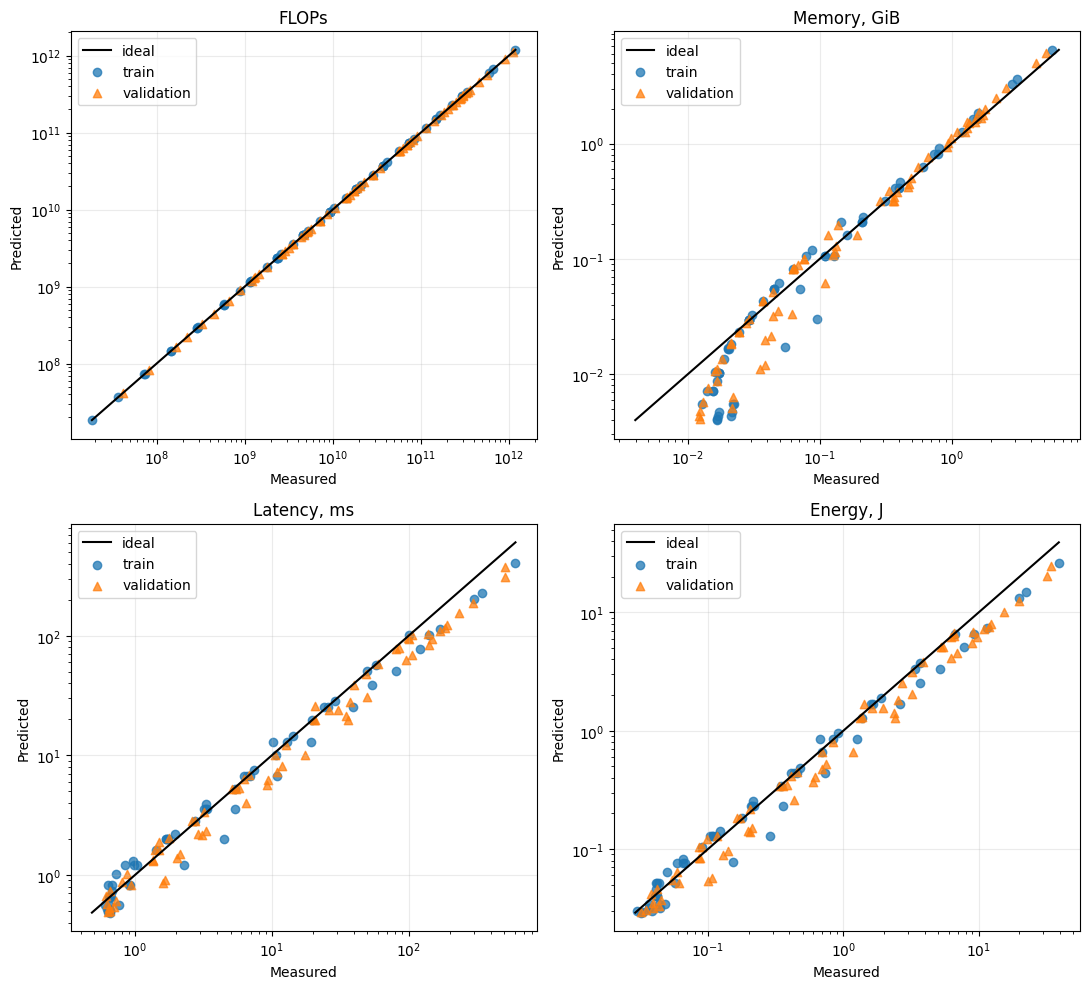

In [16]:
def save_figure(figure, filename):
    figure.tight_layout()
    figure.savefig(FIGURES_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(figure)


feasible = measurements.loc[~measurements["oom"].astype(bool)].copy()
comparison_specs = [
    ("profiler_flops", "flops_pred", "FLOPs", 1.0),
    ("memory_bytes", "memory_pred_bytes", "Memory, GiB", 2**-30),
    ("latency_s", "latency_pred_s", "Latency, ms", 1_000.0),
    ("energy_j", "energy_pred_j", "Energy, J", 1.0),
]

figure, axes = plt.subplots(2, 2, figsize=(11, 10))
for axis, (measured_column, predicted_column, title, scale) in zip(
    axes.flat, comparison_specs
):
    valid = feasible.loc[
        np.isfinite(feasible[measured_column]) & (feasible[measured_column] > 0)
    ]
    all_values = np.concatenate(
        [valid[measured_column].to_numpy(), valid[predicted_column].to_numpy()]
    ) * scale
    lower, upper = all_values.min(), all_values.max()
    axis.plot([lower, upper], [lower, upper], color="black", label="ideal")
    for validation, label, marker in (
        (False, "train", "o"), (True, "validation", "^")
    ):
        points = valid.loc[valid["is_validation"].astype(bool) == validation]
        axis.scatter(
            points[measured_column] * scale, points[predicted_column] * scale,
            marker=marker, alpha=0.75, label=label,
        )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Measured")
    axis.set_ylabel("Predicted")
    axis.set_title(title)
    axis.grid(alpha=0.25)
    axis.legend()

save_figure(figure, "predicted_vs_measured.png")

## Scaling with batch size, latency regimes and errors

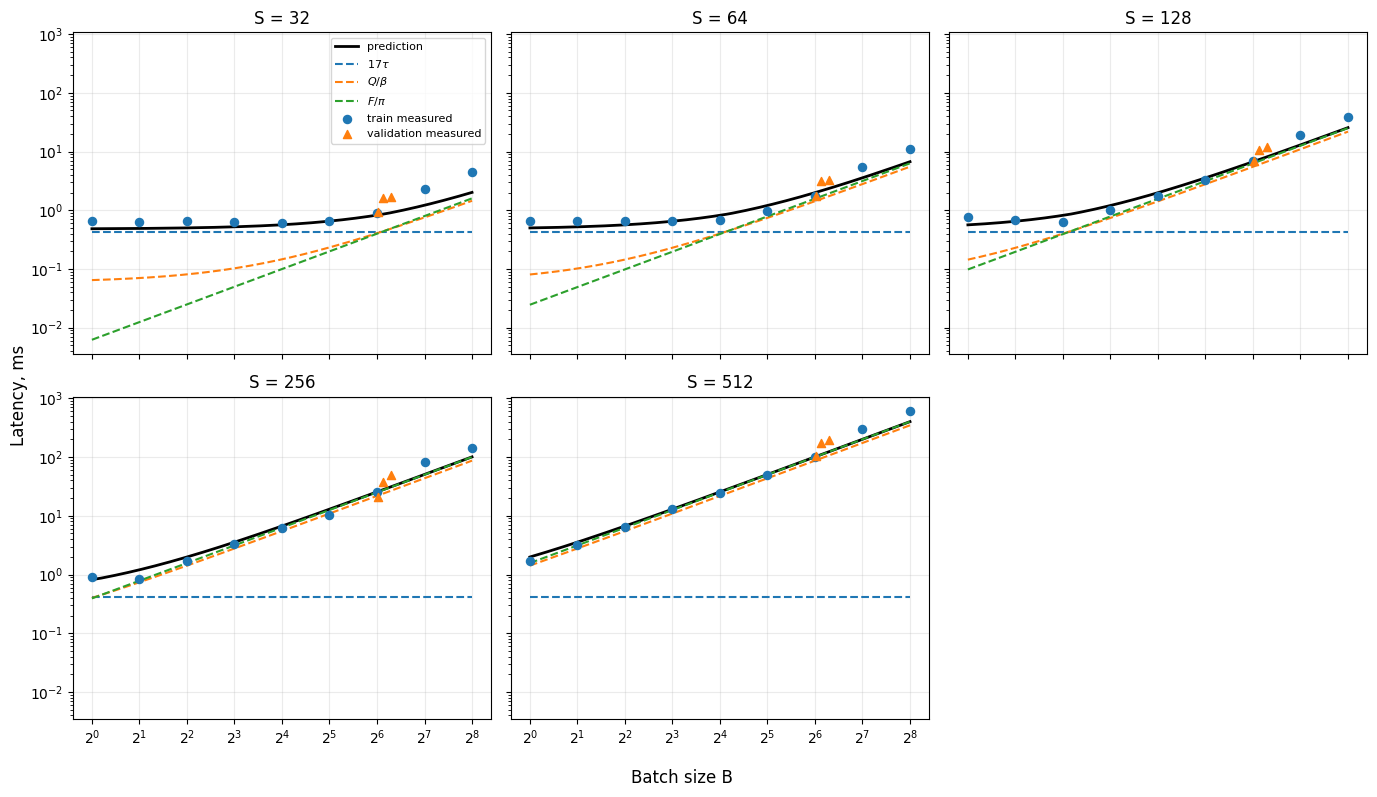

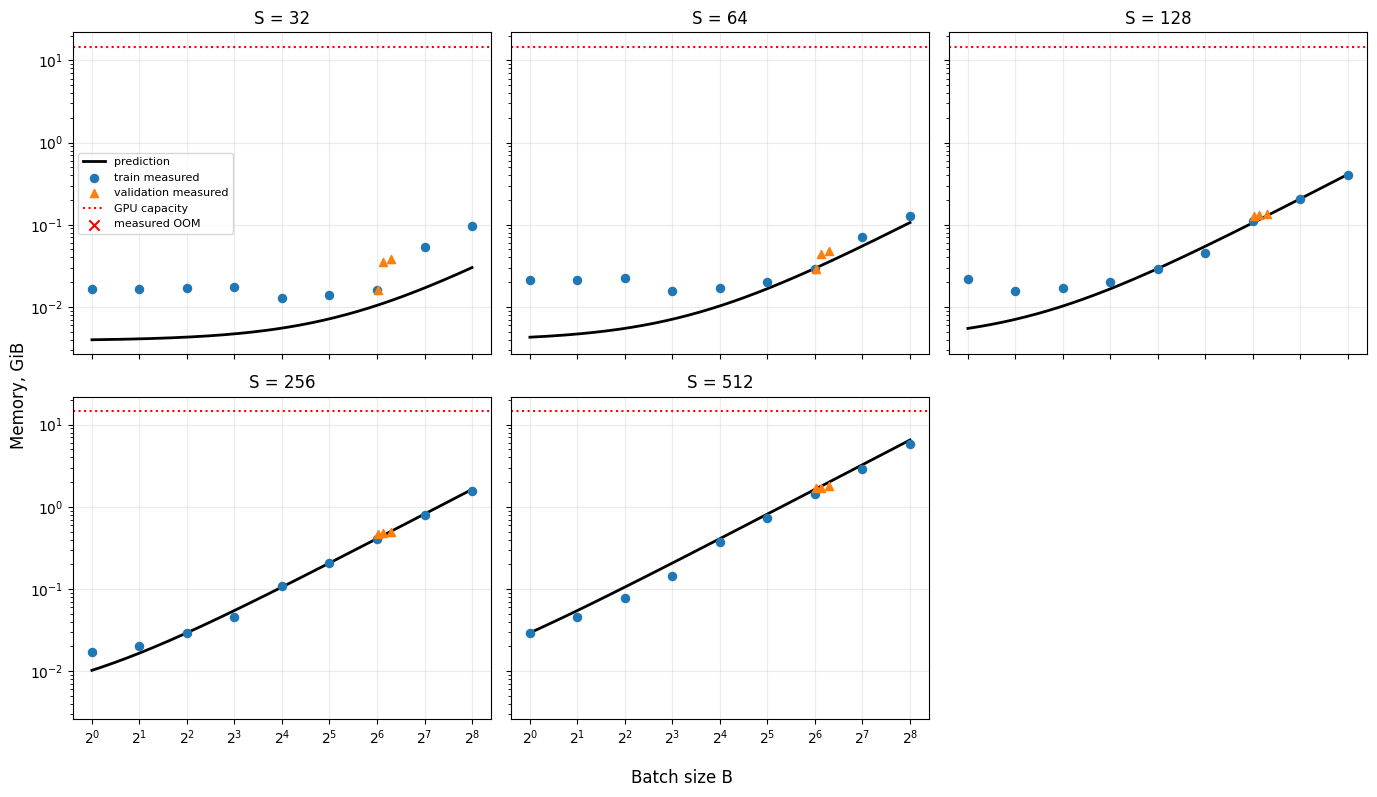

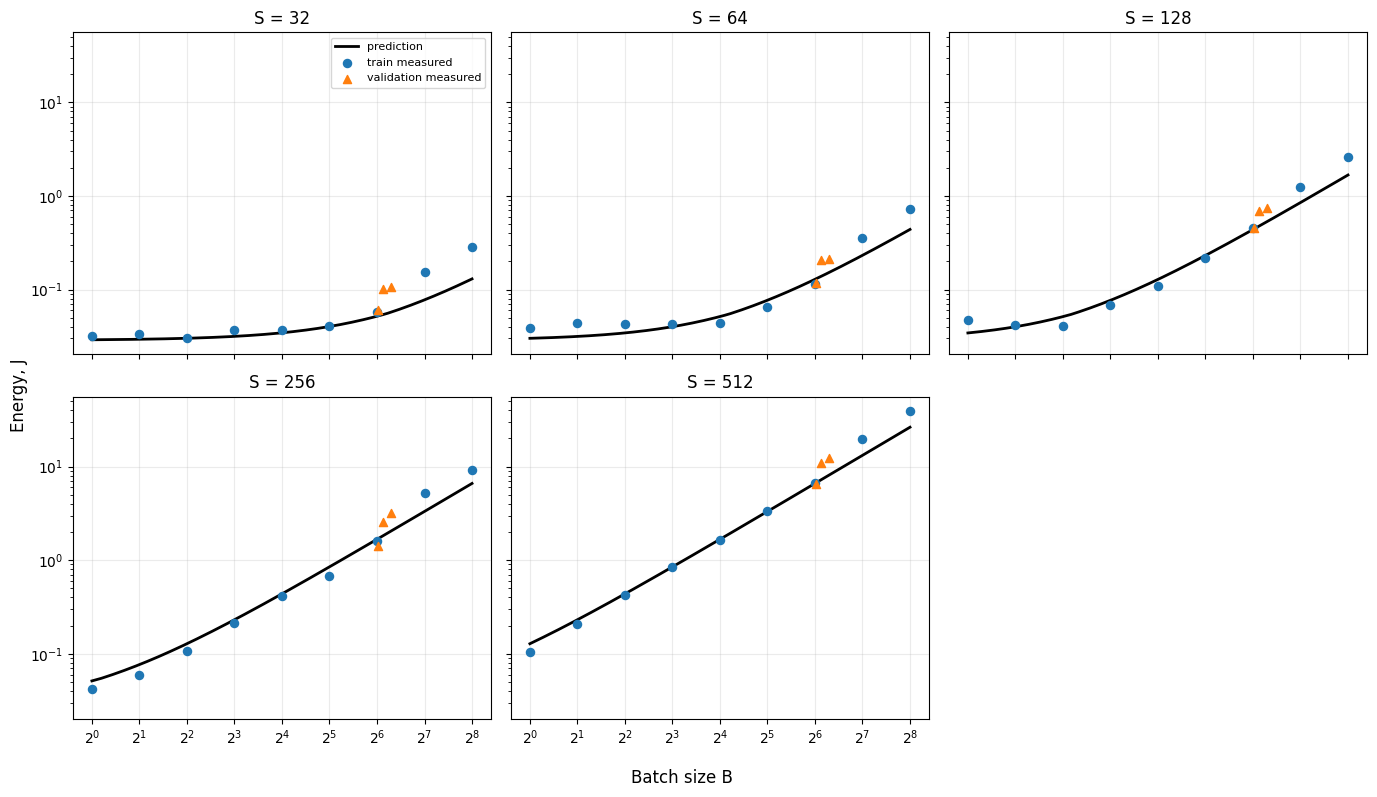

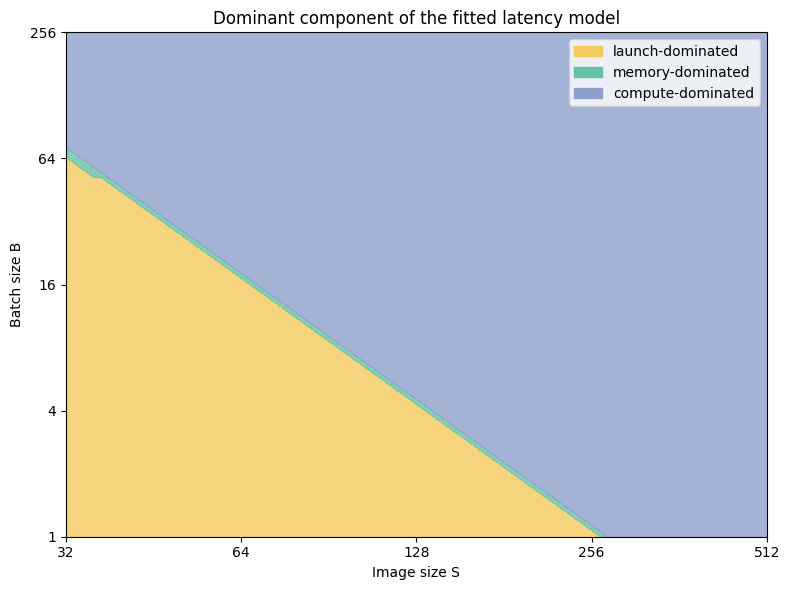

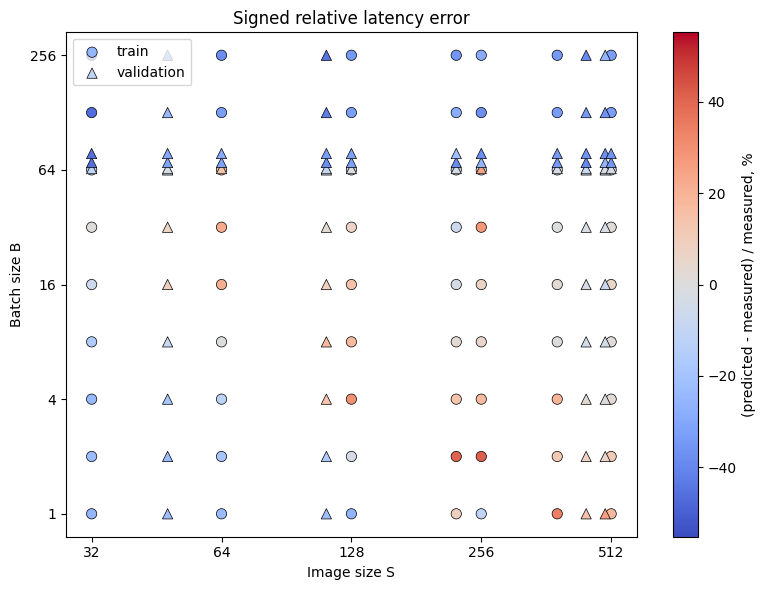

{
  "latency": {
    "train": {
      "count": 63,
      "mape_percent": 17.874979104437557,
      "rmse": 0.03418901004687149
    },
    "validation": {
      "count": 69,
      "mape_percent": 20.18327539159995,
      "rmse": 0.03767777698991817
    }
  },
  "energy": {
    "train": {
      "count": 63,
      "mape_percent": 17.12695917283891,
      "rmse": 2.1866578842896685
    },
    "validation": {
      "count": 69,
      "mape_percent": 19.876263840775067,
      "rmse": 2.4089763235654416
    }
  }
}


In [20]:
from matplotlib.colors import ListedColormap, TwoSlopeNorm
from matplotlib.patches import Patch

selected_sizes = [32, 64, 128, 256, 512]
smooth_batches = np.geomspace(1, 256, 200)

figure, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for axis, image_size in zip(axes.flat, selected_sizes):
    launch_component = np.full_like(
        smooth_batches, 17 * latency_theta["tau_s"] * 1_000
    )
    memory_component = (
        bytes_moved(image_size, smooth_batches)
        / latency_theta["bandwidth_bytes_per_s"]
        * 1_000
    )
    compute_component = (
        flops(image_size, smooth_batches)
        / latency_theta["throughput_flops_per_s"]
        * 1_000
    )
    predicted = latency(image_size, smooth_batches, latency_theta) * 1_000
    axis.plot(smooth_batches, predicted, color="black", linewidth=2, label="prediction")
    axis.plot(smooth_batches, launch_component, "--", label=r"$17\tau$")
    axis.plot(smooth_batches, memory_component, "--", label=r"$Q/\beta$")
    axis.plot(smooth_batches, compute_component, "--", label=r"$F/\pi$")
    points = feasible.loc[feasible["image_size"] == image_size]
    for validation, label, marker in (
        (False, "train measured", "o"),
        (True, "validation measured", "^"),
    ):
        split = points.loc[points["is_validation"].astype(bool) == validation]
        axis.scatter(
            split["batch"], split["latency_s"] * 1_000,
            marker=marker, s=34, zorder=3, label=label,
        )
    axis.set_title(f"S = {image_size}")
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.grid(alpha=0.25)

axes.flat[-1].axis("off")
axes[0, 0].legend(fontsize=8)
figure.supxlabel("Batch size B")
figure.supylabel("Latency, ms")
save_figure(figure, "latency_vs_batch.png")


def plot_metric_vs_batch(
    predict, measured_column, ylabel, filename, scale=1.0, show_oom=False
):
    figure, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
    for axis, image_size in zip(axes.flat, selected_sizes):
        axis.plot(
            smooth_batches, predict(image_size, smooth_batches) * scale,
            color="black", linewidth=2, label="prediction",
        )
        points = feasible.loc[feasible["image_size"] == image_size]
        for validation, label, marker in (
            (False, "train measured", "o"),
            (True, "validation measured", "^"),
        ):
            split = points.loc[points["is_validation"].astype(bool) == validation]
            axis.scatter(
                split["batch"], split[measured_column] * scale,
                marker=marker, s=34, zorder=3, label=label,
            )
        if show_oom:
            capacity = measurements["gpu_total_memory_bytes"].iloc[0] * scale
            axis.axhline(capacity, color="red", linestyle=":", label="GPU capacity")
            oom = measurements.loc[
                measurements["oom"].astype(bool)
                & (measurements["image_size"] == image_size)
            ]
            axis.scatter(
                oom["batch"], np.full(len(oom), capacity),
                marker="x", color="red", s=55, label="measured OOM",
            )
        axis.set_title(f"S = {image_size}")
        axis.set_xscale("log", base=2)
        axis.set_yscale("log")
        axis.grid(alpha=0.25)
    axes.flat[-1].axis("off")
    axes[0, 0].legend(fontsize=8)
    figure.supxlabel("Batch size B")
    figure.supylabel(ylabel)
    save_figure(figure, filename)


plot_metric_vs_batch(
    memory, "memory_bytes", "Memory, GiB", "memory_vs_batch.png",
    scale=2**-30, show_oom=True,
)
plot_metric_vs_batch(
    lambda s, b: energy(s, b, energy_theta),
    "energy_j", "Energy, J", "energy_vs_batch.png",
)

surface_sizes = np.geomspace(32, 512, 100)
surface_batches = np.geomspace(1, 256, 100)
surface_s, surface_b = np.meshgrid(surface_sizes, surface_batches)
launch_time = np.full_like(surface_s, 17 * latency_theta["tau_s"])
memory_time = bytes_moved(surface_s, surface_b) / latency_theta["bandwidth_bytes_per_s"]
compute_time = flops(surface_s, surface_b) / latency_theta["throughput_flops_per_s"]
dominant = np.argmax(np.stack([launch_time, memory_time, compute_time]), axis=0)
regime_colors = ["#f4c95d", "#66c2a5", "#8da0cb"]

figure, axis = plt.subplots(figsize=(8, 6))
axis.contourf(
    surface_s, surface_b, dominant, levels=[-0.5, 0.5, 1.5, 2.5],
    cmap=ListedColormap(regime_colors), alpha=0.8,
)
axis.legend(handles=[
    Patch(color=regime_colors[0], label="launch-dominated"),
    Patch(color=regime_colors[1], label="memory-dominated"),
    Patch(color=regime_colors[2], label="compute-dominated"),
])
axis.set_xscale("log", base=2)
axis.set_yscale("log", base=2)
axis.set_xticks([32, 64, 128, 256, 512], labels=[32, 64, 128, 256, 512])
axis.set_yticks([1, 4, 16, 64, 256], labels=[1, 4, 16, 64, 256])
axis.set_xlabel("Image size S")
axis.set_ylabel("Batch size B")
axis.set_title("Dominant component of the fitted latency model")
save_figure(figure, "latency_regimes.png")

valid_latency = feasible.loc[
    np.isfinite(feasible["latency_s"]) & (feasible["latency_s"] > 0)
].copy()
valid_latency["latency_error_percent"] = 100 * (
    valid_latency["latency_pred_s"] - valid_latency["latency_s"]
) / valid_latency["latency_s"]
limit = max(valid_latency["latency_error_percent"].abs().max(), 1.0)
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
figure, axis = plt.subplots(figsize=(8, 6))
for validation, label, marker in (
    (False, "train", "o"), (True, "validation", "^")
):
    points = valid_latency.loc[
        valid_latency["is_validation"].astype(bool) == validation
    ]
    scatter = axis.scatter(
        points["image_size"], points["batch"],
        c=points["latency_error_percent"], cmap="coolwarm", norm=norm,
        marker=marker, s=55, edgecolors="black", linewidths=0.5, label=label,
    )
axis.set_xscale("log", base=2)
axis.set_yscale("log", base=2)
axis.set_xticks([32, 64, 128, 256, 512], labels=[32, 64, 128, 256, 512])
axis.set_yticks([1, 4, 16, 64, 256], labels=[1, 4, 16, 64, 256])
axis.set_xlabel("Image size S")
axis.set_ylabel("Batch size B")
axis.set_title("Signed relative latency error")
axis.legend()
figure.colorbar(scatter, ax=axis, label="(predicted - measured) / measured, %")
save_figure(figure, "latency_error_map.png")

print(json.dumps(theta["metrics"], indent=2))

## Final artifact check

In [18]:
print(f"Measurements: {MEASUREMENTS_PATH}")
print(f"Parameters: {THETA_PATH}")
print(f"Figures: {sorted(path.name for path in FIGURES_DIR.glob('*.png'))}")

Measurements: results/measurements.csv
Parameters: results/theta.json
Figures: ['energy_contours.png', 'energy_surface.png', 'energy_vs_batch.png', 'errors.png', 'errors_and_oom.png', 'flops_contours.png', 'flops_surface.png', 'latency_contours.png', 'latency_error_map.png', 'latency_regimes.png', 'latency_surface.png', 'latency_vs_batch.png', 'memory_contours.png', 'memory_surface.png', 'memory_vs_batch.png', 'predicted_vs_measured.png']
